In [80]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
from scipy import stats
import seaborn as sns
from wordcloud import WordCloud
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from imblearn.under_sampling import TomekLinks
from imblearn.over_sampling import SMOTE, ADASYN
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_auc_score,
    precision_recall_curve,
    roc_curve,
    auc
)

from nltk.tokenize import word_tokenize
# Error:
"""
LookupError: 
**********************************************************************
  Resource punkt not found.
  Please use the NLTK Downloader to obtain the resource:

  >>> import nltk
  >>> nltk.download('punkt')
  
  For more information see: https://www.nltk.org/data.html

  Attempted to load tokenizers/punkt/english.pickle

  Searched in:
    - 'C:\\Users\\krita/nltk_data'
    - 'D:\\Y3S1 Applied Machine Learning(Retake)\\Workspace\\AML_Retake\\nltk_data'
    - 'D:\\Y3S1 Applied Machine Learning(Retake)\\Workspace\\AML_Retake\\share\\nltk_data'
    - 'D:\\Y3S1 Applied Machine Learning(Retake)\\Workspace\\AML_Retake\\lib\\nltk_data'
    - 'C:\\Users\\krita\\AppData\\Roaming\\nltk_data'
    - 'C:\\nltk_data'
    - 'D:\\nltk_data'
    - 'E:\\nltk_data'
    - ''
**********************************************************************
"""
# Source - https://stackoverflow.com/a
# Posted by alok, modified by community. See post 'Timeline' for change history
# Retrieved 2026-01-07, License - CC BY-SA 4.0
# nltk.download('punkt')
# nltk.download('wordnet')
# nltk.download('omw-1.4')

# Error:
"""
LookupError: 
**********************************************************************
  Resource stopwords not found.
  Please use the NLTK Downloader to obtain the resource:

  >>> import nltk
  >>> nltk.download('stopwords')
  
  For more information see: https://www.nltk.org/data.html

  Attempted to load corpora/stopwords

  Searched in:
    - 'C:\\Users\\krita/nltk_data'
    - 'D:\\Y3S1 Applied Machine Learning(Retake)\\Workspace\\AML_Retake\\nltk_data'
    - 'D:\\Y3S1 Applied Machine Learning(Retake)\\Workspace\\AML_Retake\\share\\nltk_data'
    - 'D:\\Y3S1 Applied Machine Learning(Retake)\\Workspace\\AML_Retake\\lib\\nltk_data'
    - 'C:\\Users\\krita\\AppData\\Roaming\\nltk_data'
    - 'C:\\nltk_data'
    - 'D:\\nltk_data'
    - 'E:\\nltk_data'
**********************************************************************
"""
# nltk.download("stopwords")

from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords

In [2]:
df = pd.read_csv("spam_mail.csv")

In [3]:
df.head()

,Category,Masseges
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [4]:
df.info

<bound method DataFrame.info of      Category                                           Masseges
0         ham  Go until jurong point, crazy.. Available only ...
1         ham                      Ok lar... Joking wif u oni...
2        spam  Free entry in 2 a wkly comp to win FA Cup fina...
3         ham  U dun say so early hor... U c already then say...
4         ham  Nah I don't think he goes to usf, he lives aro...
...       ...                                                ...
5567     spam  This is the 2nd time we have tried 2 contact u...
5568      ham              Will Ì_ b going to esplanade fr home?
5569      ham  Pity, * was in mood for that. So...any other s...
5570      ham  The guy did some bitching but I acted like i'd...
5571      ham                         Rofl. Its true to its name

[5572 rows x 2 columns]>

In [5]:
df.nunique

<bound method DataFrame.nunique of      Category                                           Masseges
0         ham  Go until jurong point, crazy.. Available only ...
1         ham                      Ok lar... Joking wif u oni...
2        spam  Free entry in 2 a wkly comp to win FA Cup fina...
3         ham  U dun say so early hor... U c already then say...
4         ham  Nah I don't think he goes to usf, he lives aro...
...       ...                                                ...
5567     spam  This is the 2nd time we have tried 2 contact u...
5568      ham              Will Ì_ b going to esplanade fr home?
5569      ham  Pity, * was in mood for that. So...any other s...
5570      ham  The guy did some bitching but I acted like i'd...
5571      ham                         Rofl. Its true to its name

[5572 rows x 2 columns]>

In [6]:
df.isnull().sum()

Category    0
Masseges    0
dtype: int64

In [7]:
# Correcting the 'Masseges' typo
df.rename(columns={'Masseges': 'Messages'}, inplace=True)
df

,Category,Messages
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will Ì_ b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


In [8]:
df['message_length'] = df['Messages'].apply(lambda x: len(x))
df.head()                                             

,Category,Messages,message_length
0,ham,"Go until jurong point, crazy.. Available only ...",111
1,ham,Ok lar... Joking wif u oni...,29
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,ham,U dun say so early hor... U c already then say...,49
4,ham,"Nah I don't think he goes to usf, he lives aro...",61


In [9]:
# preprocessing functions

def search_urls(text):
    return len(re.findall(r'https?://\S+|www\.\S+', text))
    
def search_emails(text):
    return len(re.findall(r'\S+@\S+', text)) 

def convert_to_lowercase(text):
    return text.lower()

def remove_numbers(text):
    return re.sub(r'\d+', '', text)

def remove_punctuation(text):
    return re.sub(r'[^\w\s]', '', text)

def remove_extra_white_spaces(text):
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

def remove_stopwords(text):
    tokens = word_tokenize(text)
    stop_words = set(stopwords.words('english'))
    filtered_words = [word 
                      for word in tokens if word not in stop_words]
    return " ".join(filtered_words)

def lemmatize_words(text):
    lemmatizer = WordNetLemmatizer()
    tokens = word_tokenize(text)
    lemmatized_words = [lemmatizer.lemmatize(word) for word in tokens]
    return " ".join(lemmatized_words)

# Function to correct spellings and typos

In [10]:
# Since emails and urls are a strong indicators for spam mail,
# features url_count and email_count are introduced.
df['url_count'] = df['Messages'].apply(lambda x: search_urls(x))
df['email_count'] = df['Messages'].apply(lambda x: search_emails(x))

In [11]:
# Applying preprocessing functions to Messages
df['Messages'] = df['Messages'].apply(lambda x: convert_to_lowercase(x))
df['Messages'] = df['Messages'].apply(lambda x: remove_numbers(x))
df['Messages'] = df['Messages'].apply(lambda x: remove_punctuation(x))
df['Messages'] = df['Messages'].apply(lambda x: remove_extra_white_spaces(x))
df['Messages'] = df['Messages'].apply(lambda x: remove_stopwords(x))
df['Messages'] = df['Messages'].apply(lambda x: lemmatize_words(x))

In [12]:
df['message_length_after_preprocessing'] = df['Messages'].apply(lambda x: len(x))
df.head(20)    

,Category,Messages,message_length,url_count,email_count,message_length_after_preprocessing
0,ham,go jurong point crazy available bugis n great ...,111,0,0,82
1,ham,ok lar joking wif u oni,29,0,0,23
2,spam,free entry wkly comp win fa cup final tkts st ...,155,0,0,106
3,ham,u dun say early hor u c already say,49,0,0,35
4,ham,nah dont think go usf life around though,61,0,0,40
5,spam,freemsg hey darling week word back id like fun...,148,0,0,82
6,ham,even brother like speak treat like aid patent,77,0,0,45
7,ham,per request melle melle oru minnaminunginte nu...,160,0,0,109
8,spam,winner valued network customer selected receiv...,158,0,0,99
9,spam,mobile month u r entitled update latest colour...,154,0,0,92


In [13]:
# Dropping unnecessary columns
df = df.drop(columns=['message_length', 'message_length_after_preprocessing'])
df.head()

,Category,Messages,url_count,email_count
0,ham,go jurong point crazy available bugis n great ...,0,0
1,ham,ok lar joking wif u oni,0,0
2,spam,free entry wkly comp win fa cup final tkts st ...,0,0
3,ham,u dun say early hor u c already say,0,0
4,ham,nah dont think go usf life around though,0,0


In [14]:
# Label Encoding
category_map = {
    'ham' : 0,
    'spam' : 1
}
df['Category'] = df['Category'].map(category_map)
df.head()

,Category,Messages,url_count,email_count
0,0,go jurong point crazy available bugis n great ...,0,0
1,0,ok lar joking wif u oni,0,0
2,1,free entry wkly comp win fa cup final tkts st ...,0,0
3,0,u dun say early hor u c already say,0,0
4,0,nah dont think go usf life around though,0,0


In [15]:
# Word Cloud Generation
spam_messages = df[df['Category'] == 1]['Messages'].str.cat(sep=' ')
ham_messages = df[df['Category'] == 0]['Messages'].str.cat(sep=' ')

# Word Cloud for Spam
spam_wordcloud = WordCloud(width=1600, height=1000, 
                           background_color='white', 
                           min_font_size=10).generate(spam_messages)

# Word Cloud for Ham
ham_wordcloud = WordCloud(width=1600, height=1000, 
                          background_color='white', 
                          min_font_size=10).generate(ham_messages)

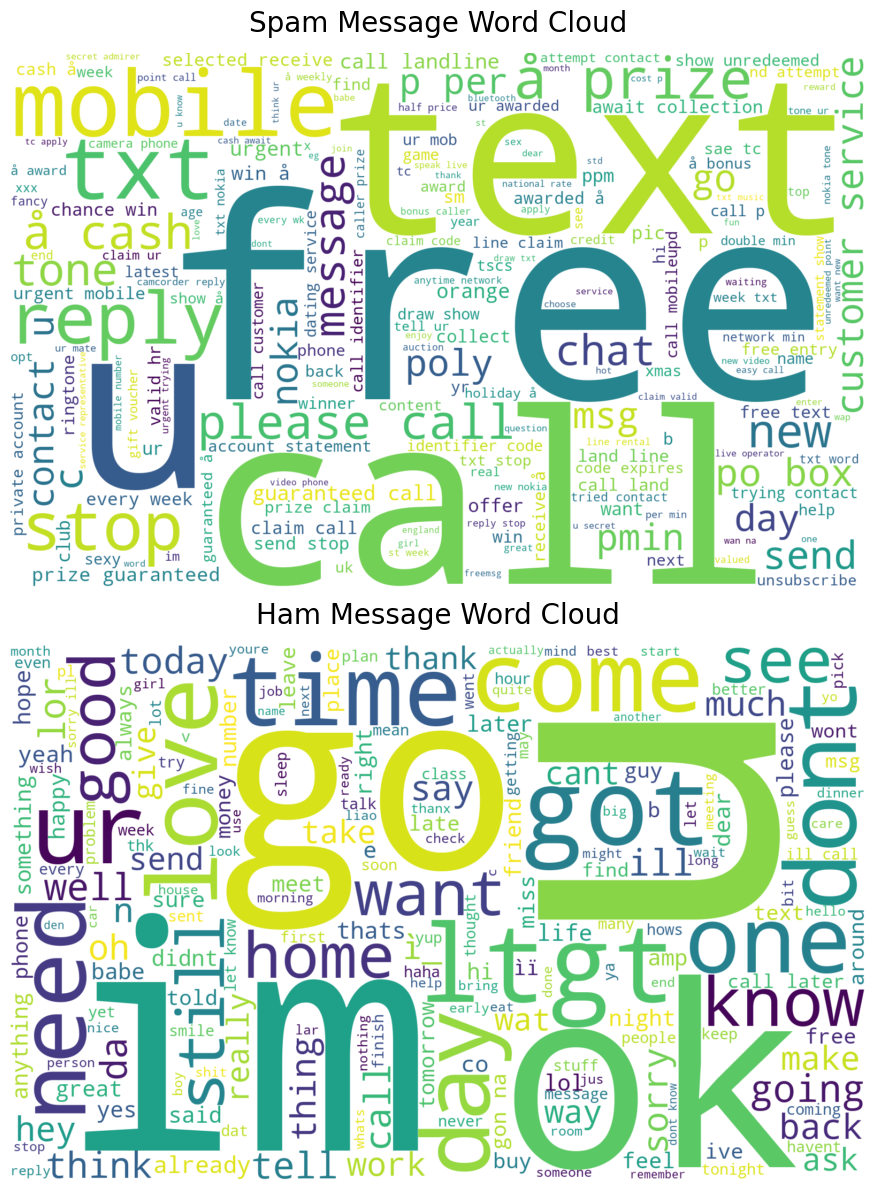

In [16]:
# Word Cloud Visualization
plt.figure(figsize=(15, 12))

# Plot Spam Word Cloud
plt.subplot(2, 1, 1)
plt.imshow(spam_wordcloud, interpolation='bilinear')
plt.title('Spam Message Word Cloud', 
          fontsize=20,                
          pad=15)                
plt.axis('off')

# Plot Ham Word Cloud
plt.subplot(2, 1, 2)
plt.imshow(ham_wordcloud, interpolation='bilinear')
plt.title('Ham Message Word Cloud', 
          fontsize=20, 
          pad=15)
plt.axis('off')

plt.tight_layout()
plt.show()

In [17]:
# Vectorization
corpus = df['Messages']

# TF-IDF Values Calculation
tfidf = TfidfVectorizer()
result = tfidf.fit_transform(corpus)
features = result.toarray()

In [18]:
# train test split
X_train, X_test, y_train, y_test = train_test_split(features, df['Category'].values, test_size=0.3, random_state = 42)

In [19]:
# Checking for presence of class imbalance
count_target = np.unique(y_train, return_counts = True)
count_target

(array([0, 1], dtype=int64), array([3372,  528], dtype=int64))

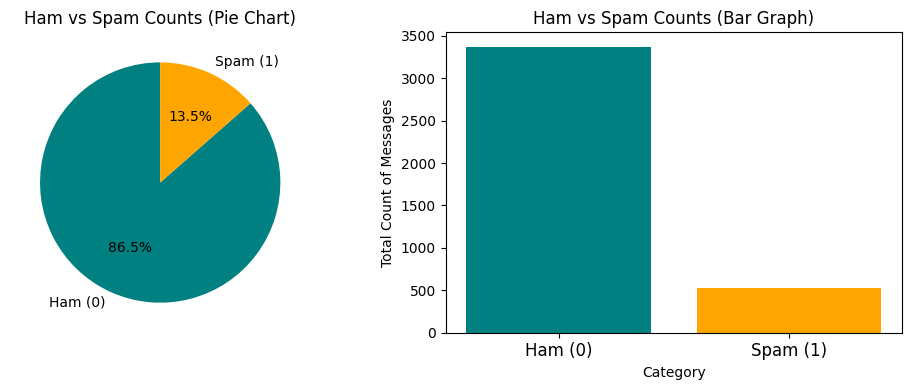

In [20]:
# Graphical Representation
index, count = count_target
plt.figure(figsize = (10, 4))

# Pie Chart for Class Distribution
plt.subplot(1, 2, 1)

# Calculate percentages
total = sum(count)
percentages = [c/total*100 for c in count]

plt.pie(
    count, 
    labels = ['Ham (0)', 'Spam (1)'], 
    autopct='%1.1f%%',
    startangle=90,
    colors = ['teal', 'orange'],
)
plt.title("Ham vs Spam Counts (Pie Chart)")

# Bar Graph for Class Distribution
plt.subplot(1, 2, 2)
plt.bar(
    index, 
    count, 
    color=['teal', 'orange']
)
plt.xticks(index, ['Ham (0)', 'Spam (1)'], fontsize=12)
plt.title("Ham vs Spam Counts (Bar Graph)")
plt.xlabel("Category")
plt.ylabel("Total Count of Messages")

plt.tight_layout()
plt.show()

In [21]:
# Ham Messages: 3372 i.e., ~86.5% of the dataset
# Spam Messages: 528 i.e., ~13.5% of the dataset
# There is an imbalance of class where ham messages heavily dominates the dataset.
# Even if the model predicts all messages as ham, it will have an accuracy of ~86.46%.

In [22]:
# Function to plot class distribution after resampling
def plot_resampling_results(y_resampled, title):
    index, count = np.unique(y_resampled, return_counts = True)
    
    total = sum(count)
    percentages = [c/total*100 for c in count]
    
    plt.pie(
        count, 
        labels = ['Ham (0)', 'Spam (1)'], 
        autopct='%1.1f%%',
        startangle=90,
        colors = ['teal', 'orange'],
    )
    plt.title(title)
    plt.show()

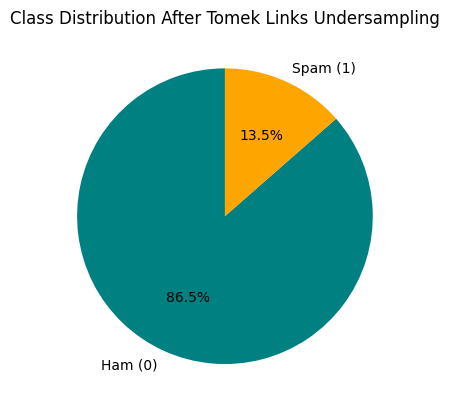

In [23]:
# Solving Class Imbalance with TomekLinks Undersampling
tomek = TomekLinks()
X_tl_train, y_tl_train = tomek.fit_resample(X_train, y_train)
plot_resampling_results(y_tl_train, 'Class Distribution After Tomek Links Undersampling')

In [24]:
# Due to absence of borderline data, no change was observed in the dataset.

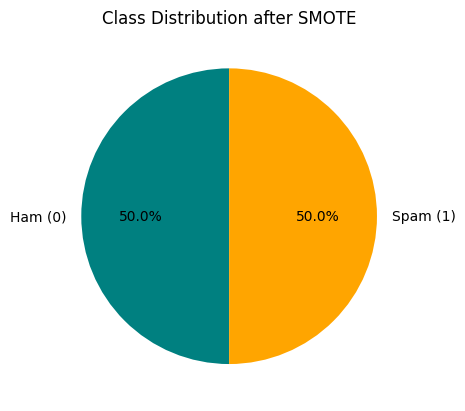

In [25]:
# Solving Class Imbalance with SMOTE 
smote = SMOTE(random_state = 123)
X_smote_train, y_smote_train = smote.fit_resample(X_train, y_train)
plot_resampling_results(y_smote_train, 'Class Distribution after SMOTE')

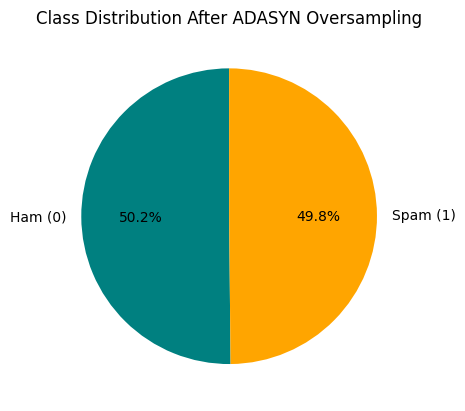

In [26]:
# Solving Class Imbalance with ADASYN oversampling
adasyn = ADASYN(random_state = 123)
X_adasyn_train, y_adasyn_train = adasyn.fit_resample(X_train, y_train)
plot_resampling_results(y_adasyn_train, 'Class Distribution After ADASYN Oversampling')

<h3>Model Selection</h3>

In [99]:
# Multinomial Naive Bayes Model
def train_MNB_model(X_train, y_train, X_test):
    model = MultinomialNB()
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    
    return y_pred, y_pred_proba

def evaluate_model(y_test, y_pred, y_pred_proba):
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, pos_label=1)
    recall = recall_score(y_test, y_pred, pos_label=1)
    f1 = f1_score(y_test, y_pred, pos_label=1)
    cf_matrix = confusion_matrix(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_proba, average = None)
    fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
    pr_auc_curve = precision_recall_curve(y_test, y_pred)

    evaluation_metrics = {
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1_Score': f1,
        'Confusion_Matrix': cf_matrix,
        'roc_auc_score': roc_auc,
        'roc_curve': (fpr, tpr, thresholds),
        'pr_auc_curve': pr_auc_curve
    }
    
    return evaluation_metrics

def display_metrics(evaluation_metrics):
    print(f'Accuracy: {evaluation_metrics.get("Accuracy")}')
    print(f'Precision: {evaluation_metrics.get("Precision")}')
    print(f'Recall: {evaluation_metrics.get("Recall")}')
    print(f'F1 Score: {evaluation_metrics.get("F1_Score")}')
    print(f'ROC AUC Score: {evaluation_metrics.get("roc_auc_score")}')
    
    class_labels = ['Ham (0)', 'Spam (1)'] 

    plt.figure(figsize=(8, 18))
    
    # Confusion Matrix
    plt.subplot(3, 1, 1)
    sns.heatmap(
        evaluation_metrics.get("Confusion_Matrix"), 
        annot=True,          
        fmt='d',             
        cmap='Blues',        
        xticklabels = class_labels, 
        yticklabels=class_labels  
    )
    
    plt.title('Confusion Matrix')

    # roc_auc_curve
    fpr, tpr, thresholds = evaluation_metrics.get('roc_curve')
    plt.subplot(3, 1, 2)
    plt.plot(
        fpr, 
        tpr,
        color = 'orange',
        lw = 2,
        label = f"ROC Curve (AUC = {evaluation_metrics.get('roc_auc_score')})"
    )
    plt.xlabel('False Positive Rate (1 - Specificity)')
    plt.ylabel('True Positive Rate (Sensitivity/Recall)')
    plt.title('ROC Curve')
    plt.legend(loc="lower right", fontsize=11)
    plt.grid(True)

    # pr_auc curve
    precision, recall, thresholds = evaluation_metrics.get('pr_auc_curve')
    pr_auc_score = auc(recall, precision)

    plt.subplot(3, 1, 3)
    plt.plot(
        recall, 
        precision, 
        label=f'Precision-Recall Curve (AUC = {pr_auc_score})'
    )
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Precision-Recall Curve')
    plt.legend()

    plt.tight_layout()
    plt.show()

Accuracy: 0.9611244019138756
Precision: 0.8130081300813008
Recall: 0.91324200913242
F1 Score: 0.8602150537634409
ROC AUC Score: 0.9828822118935159


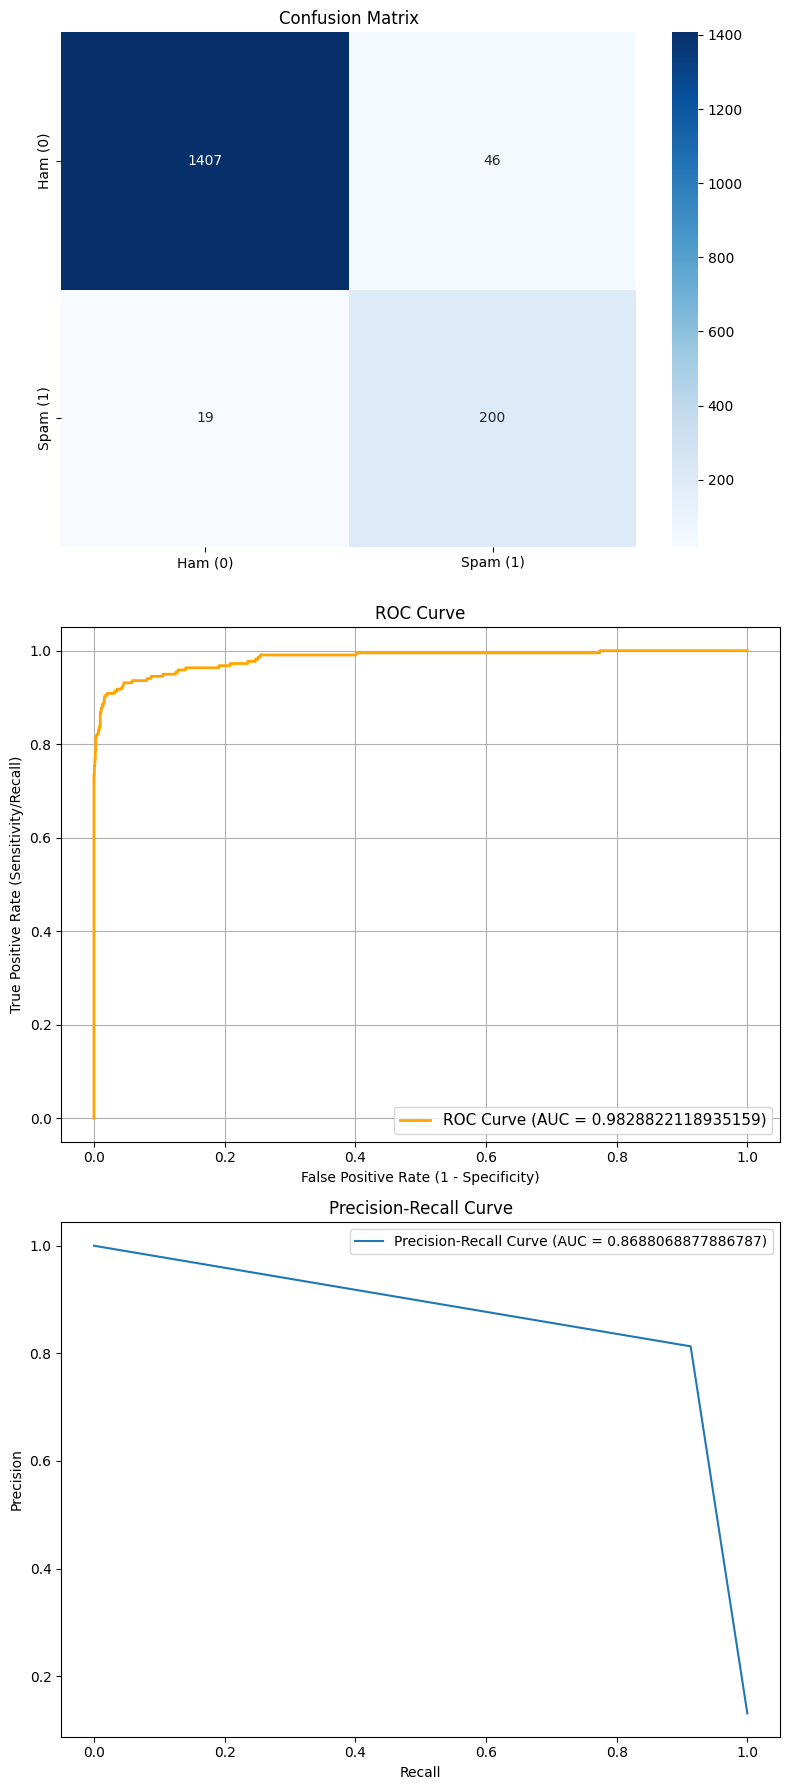

In [100]:
# Training and Evaluation on resampled data using SMOTE
smote_MNB_y_pred, smote_MNB_y_pred_proba = train_MNB_model(
    X_smote_train, 
    y_smote_train, 
    X_test
)
smote_MNB_metrics = evaluate_model(
    y_test, 
    smote_MNB_y_pred,
    smote_MNB_y_pred_proba
)
display_metrics(smote_MNB_metrics)

Accuracy: 0.958732057416268
Precision: 0.79296875
Recall: 0.9269406392694064
F1 Score: 0.8547368421052632
ROC AUC Score: 0.984503797842285


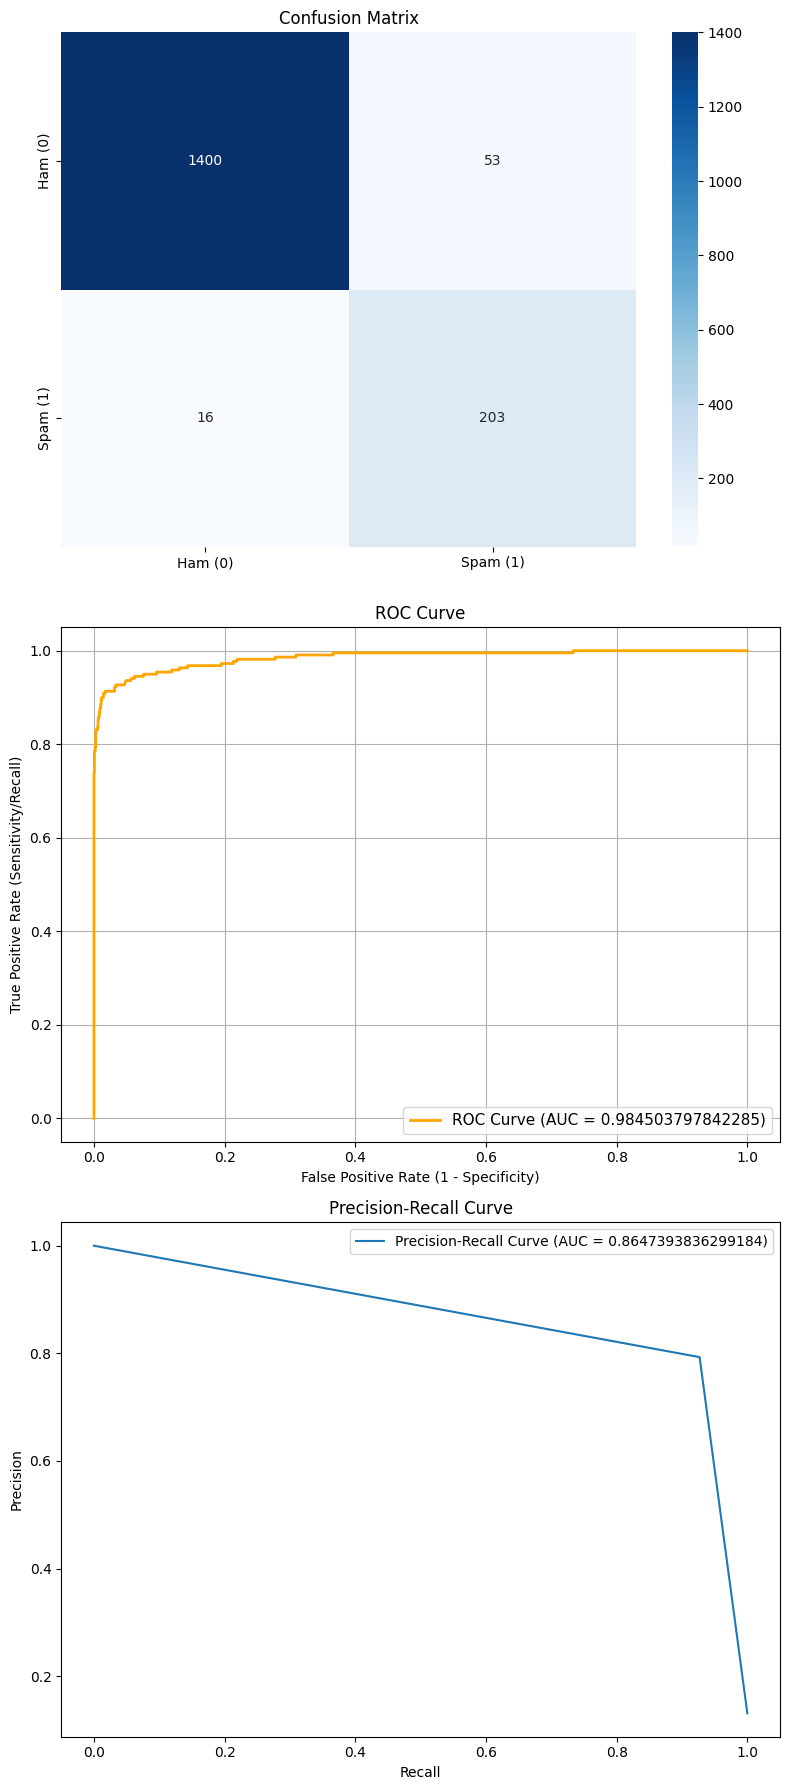

In [101]:
# Training and Evaluation on resampled data using ADASYN Oversampling
adasyn_MNB_y_pred, adasyn_MNB_y_pred_proba = train_MNB_model(
    X_adasyn_train, 
    y_adasyn_train, 
    X_test
)
adasyn_MNB_metrics = evaluate_model(
    y_test, 
    adasyn_MNB_y_pred,
    adasyn_MNB_y_pred_proba
)
display_metrics(adasyn_MNB_metrics)

In [30]:
# SVM Model
# def train_SVM_model():

In [31]:
# Training and Evaluation on resampled data using SMOTE
# smote_SVM_y_pred, smote_SVM_y_pred_proba = train_SVM_model(
#     X_smote_train, 
#     y_smote_train, 
#     X_test
# )
# smote_SVM_metrics = evaluate_model(
#     y_test, 
#     smote_SVM_y_pred
# )
# display_metrics(smote_SVM_metrics)

In [32]:
# comparison betwn two  

In [33]:
# TF-IDF - Mathmatical question
# shailshree.shah@islingtoncollege.edu.np